In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND6/load_band6_data.py"

In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

## Primary Beam and Centre Point

In [4]:
pb_path = band6_data_folder_path + "c2d_989_pbeam_233GHz.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

ny, nx = pb_map.shape

In [5]:
flat_index = np.nanargmax(pb_map)   # ignores NaNs, finds max
y_cen, x_cen = np.unravel_index(flat_index, pb_map.shape)

print(rf'The centre position is: (y, x) = ({y_cen}, {x_cen}), and at this position pb = {pb_map[y_cen, x_cen]}')

The centre position is: (y, x) = (858, 861), and at this position pb = 1.0


In [6]:
dr_arcsec = 0.25
dr_deg = arcsec_to_degrees(dr_arcsec)

dr_pix = arcsec_to_pixels(header, dr_arcsec)

In [7]:
r_pix = np.arange(0, nx - x_cen, dr_pix)
r_arcsec = pixels_to_arcsec(header, r_pix)


df = pd.DataFrame({
    "r_pix": r_pix,
    "r_arcsec": r_arcsec,
    "r_deg": arcsec_to_degrees(r_arcsec)
})

In [8]:
x_pos = x_cen + r_pix.astype(int)

pb_val_arr = pb_map[y_cen, x_pos].astype(np.float32).newbyteorder('=')  # native endian
sigma_r_arr = (0.03 / pb_val_arr).astype(np.float32).newbyteorder('=')

df["pb_val"] = pb_val_arr
df["sigma_r"] = sigma_r_arr

df["area_annulus"] = 2 * np.pi * df["r_deg"] * dr_deg

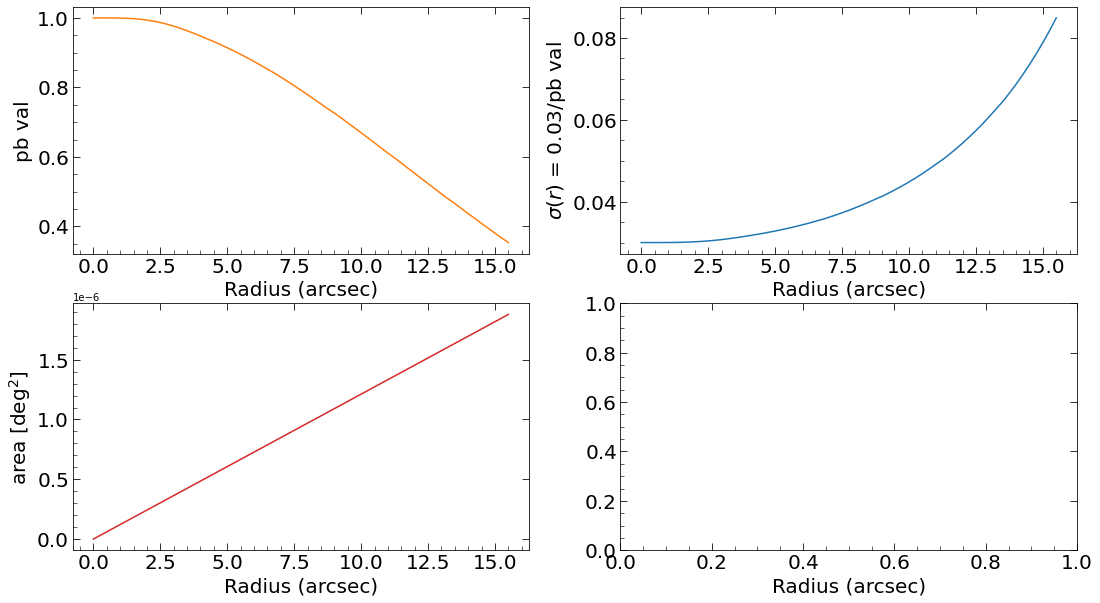

In [9]:
fig, ax = plot_galaxy_contamination_models(df)

In [10]:
# Dictionary to hold each df
df_sn_dict = {}

for sn in [5, 10, 20]:
    # Compute flux threshold per annulus
    S = sn * df["sigma_r"].values
    
    dN_dS = np.array([galaxy_probability(s, 'Band 6') for s in S])

    N_per_area_list = []

    # Loop over each annulus
    for S_min in S:
        # Use your function to integrate dN/dS above threshold
        N_per_area = find_N_from_dN_dS(S_min)
        N_per_area_list.append(N_per_area)

    N = np.array(N_per_area_list)

    # Multiply by annulus area to get expected number per annulus
    N_expected = N * df["area_annulus"].values
   
    prob = 100*(1 - np.exp(-N_expected))
    
    N_cumulative = np.cumsum(N_expected)
    prob_cumulative = 100 * (1 - np.exp(-N_cumulative))

    df_sn = pd.DataFrame({
        "r_arcsec": df["r_arcsec"].values,
        "S_mJy": S,
        "dN_dS": dN_dS,
        "N": N,
        "N_expected": N_expected,
        "prob": prob,
        "prob_cumulative": prob_cumulative
    })

    # Save in dictionary
    df_sn_dict[f"df_{sn}sigma"] = df_sn

# Access like:
df_5sigma = df_sn_dict["df_5sigma"]
df_10sigma = df_sn_dict["df_10sigma"]
df_20sigma = df_sn_dict["df_20sigma"]


In [11]:
dfs = [df_5sigma, df_10sigma, df_20sigma]
sn_array = [5, 10, 20]


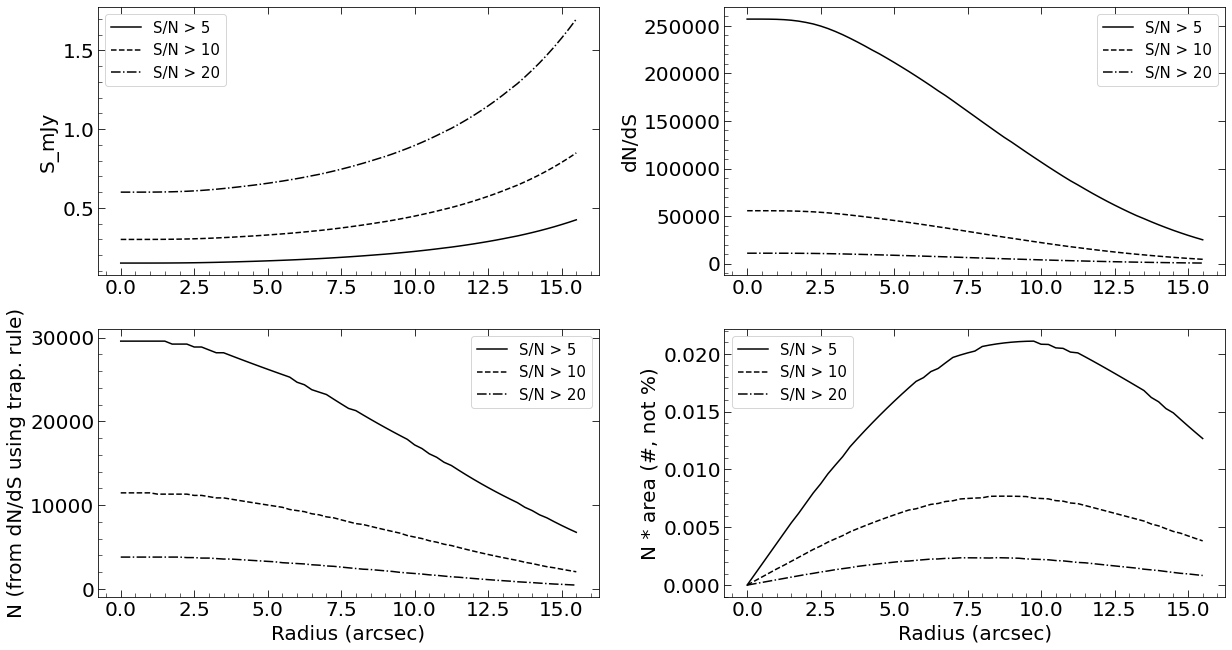

In [12]:
fig, ax = plot_probability_models(dfs, sn_array)

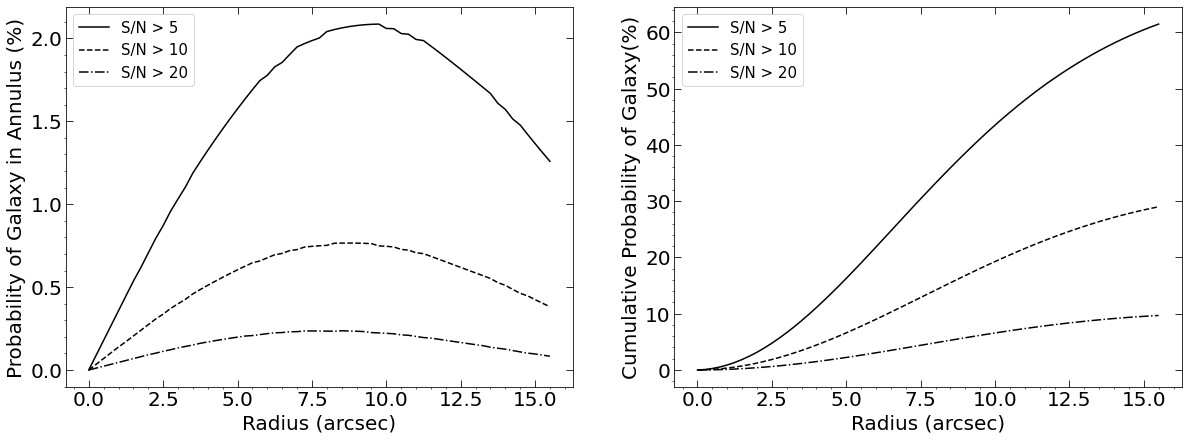

In [13]:
fig, ax = recreate_figs_11_12_sadavoy2019(dfs, sn_array)